<a href="https://colab.research.google.com/github/YHFTF/CV_HW-3/blob/main/CV_HW_3(C).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 26.4M/26.4M [00:00<00:00, 115MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 4.50MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 60.8MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.2MB/s]


Running SGD_lr0.1...
Running SGD_lr0.01...
Running SGD_lr0.001...
Running Momentum_lr0.1...
Running Momentum_lr0.01...
Running Momentum_lr0.001...
Running Adam_lr0.1...
Running Adam_lr0.01...
Running Adam_lr0.001...


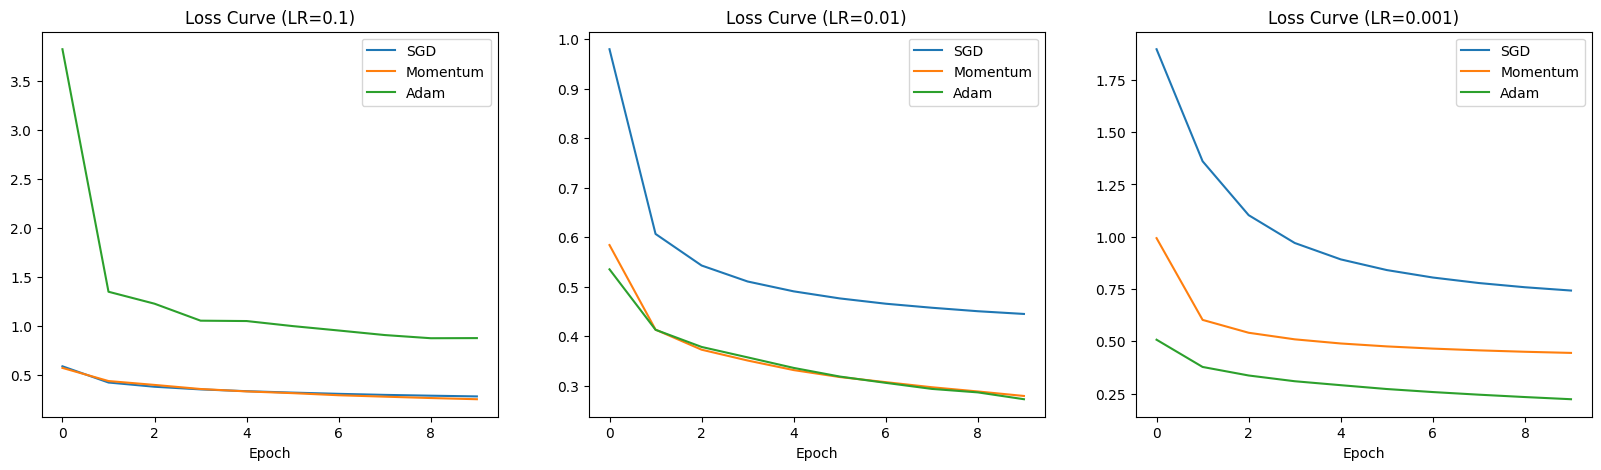

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 준비 (Fashion-MNIST)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

# 2. 동일한 네트워크 정의
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, x):
        return self.fc(x)

# 3. 실험 함수 정의
def run_experiment_c(opt_name, base_lr):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = SimpleMLP().to(device)
    criterion = nn.CrossEntropyLoss()

    # Optimizer 설정
    if opt_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=base_lr)
    elif opt_name == 'Momentum':
        optimizer = optim.SGD(model.parameters(), lr=base_lr, momentum=0.9)
    elif opt_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=base_lr)

    # [조건] Exponential Decay 스케줄러 적용
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

    history = {'loss': [], 'acc': [], 'grad_norm': []}

    for epoch in range(10): # 변별력을 위해 10 에폭 수행
        model.train()
        total_loss, correct, total = 0, 0, 0
        total_grad_norm = 0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()

            # Gradient Norm 기록
            grad_norm = sum(p.grad.norm().item() for p in model.parameters() if p.grad is not None)
            total_grad_norm += grad_norm

            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        # 에폭 끝날 때마다 스케줄러 업데이트
        scheduler.step()

        acc = 100. * correct / total
        history['loss'].append(total_loss / len(train_loader))
        history['acc'].append(acc)
        history['grad_norm'].append(total_grad_norm / len(train_loader))

    return history

# 4. 9가지 조합 실험 실행
opt_list = ['SGD', 'Momentum', 'Adam']
lr_list = [0.1, 0.01, 0.001]
results_c = {}

for opt in opt_list:
    for lr in lr_list:
        key = f"{opt}_lr{lr}"
        print(f"Running {key}...")
        results_c[key] = run_experiment_c(opt, lr)

# 5. 시각화 (LR별로 묶어서 비교)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i, lr in enumerate(lr_list):
    for opt in opt_list:
        axes[i].plot(results_c[f"{opt}_lr{lr}"]['loss'], label=opt)
    axes[i].set_title(f'Loss Curve (LR={lr})')
    axes[i].set_xlabel('Epoch')
    axes[i].legend()
plt.show()

In [2]:
import pandas as pd
import numpy as np

def summarize_optimizer_experiment(results):
    summary_data = []

    for key, hist in results.items():
        # key 예시: "Adam_lr0.1" -> 이름과 LR 분리
        name_parts = key.split('_lr')
        opt_name = name_parts[0]
        lr_val = name_parts[1]

        # 1. 최종 정확도
        final_acc = hist['acc'][-1]

        # 2. 수렴 속도: 정확도 80%에 처음 도달한 Epoch (없으면 "Fail")
        threshold = 80.0
        conv_epoch = next((i for i, v in enumerate(hist['acc']) if v >= threshold), "Fail")

        # 3. 안정성 계산: 최근 5에폭 간 Loss의 표준편차 (값이 작을수록 안정적)
        # 0.01 미만: High / 0.05 미만: Mid / 그 이상: Low
        last_loss_std = np.std(hist['loss'][-5:])
        if last_loss_std < 0.01:
            stability = "High"
        elif last_loss_std < 0.05:
            stability = "Mid"
        else:
            stability = "Low"

        summary_data.append({
            'Optimizer': opt_name,
            'Learning Rate': lr_val,
            'Final Acc (%)': f"{final_acc:.2f}",
            'Convergence (80% Epoch)': conv_epoch,
            'Stability (Loss Std)': f"{last_loss_std:.4f}",
            'Stability Grade': stability
        })

    # 데이터프레임 생성 및 정렬
    df = pd.DataFrame(summary_data)
    df = df.sort_values(by=['Optimizer', 'Learning Rate'], ascending=[True, False])

    print("\n" + "="*85)
    print(" [실험 C: Optimizer 및 Learning Rate 정량 비교 표] ")
    print("="*85)
    print(df.to_string(index=False))
    print("="*85)
    return df

# 함수 실행
comparison_c_df = summarize_optimizer_experiment(results_c)


 [실험 C: Optimizer 및 Learning Rate 정량 비교 표] 
Optimizer Learning Rate Final Acc (%) Convergence (80% Epoch) Stability (Loss Std) Stability Grade
     Adam           0.1         66.62                    Fail               0.0477             Mid
     Adam          0.01         89.92                       0               0.0157             Mid
     Adam         0.001         91.81                       0               0.0172             Mid
 Momentum           0.1         90.65                       1               0.0217             Mid
 Momentum          0.01         90.00                       1               0.0135             Mid
 Momentum         0.001         84.53                       2               0.0110             Mid
      SGD           0.1         89.82                       1               0.0137             Mid
      SGD          0.01         84.45                       2               0.0111             Mid
      SGD         0.001         75.25                    Fail   


[추가 실험] Momentum (LR=0.1) 환경에서 Batch Norm 효과 분석 중...


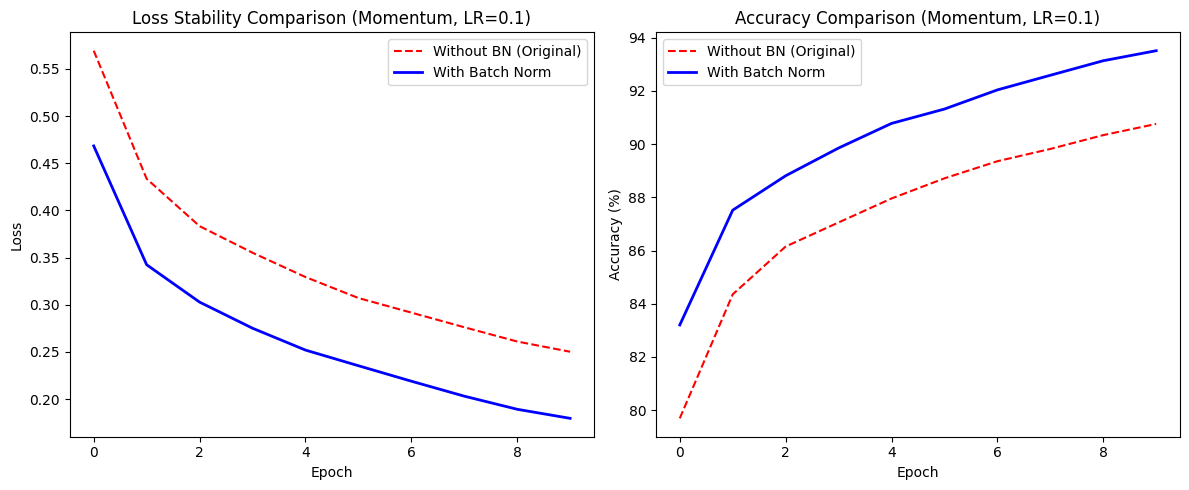

결과 요약:
- Original 최종 Acc: 90.76%
- With BN 최종 Acc: 93.51%


In [3]:
# 6. [추가 실험] 배치 정규화(Batch Normalization) 효과 검증
# 문제 해결 접근법: 고학습률에서의 오버슈팅 및 불안정성 해결

class SimpleMLPWithBN(nn.Module):
    def __init__(self, use_bn=False):
        super(SimpleMLPWithBN, self).__init__()
        self.use_bn = use_bn
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 256)
        if self.use_bn:
            self.bn1 = nn.BatchNorm1d(256) # Batch Norm 층 추가
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        if self.use_bn:
            x = self.bn1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

def run_bn_comparison(opt_name, lr, use_bn):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = SimpleMLPWithBN(use_bn=use_bn).to(device)
    criterion = nn.CrossEntropyLoss()

    if opt_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif opt_name == 'Momentum':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif opt_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)

    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
    history = {'loss': [], 'acc': []}

    for epoch in range(10):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        scheduler.step()
        history['loss'].append(total_loss / len(train_loader))
        history['acc'].append(100. * correct / total)

    return history

# 높은 학습률(0.1)에서 BN의 유무에 따른 차이 실험
test_opt = 'Momentum' # 진동이 잘 보이는 Momentum으로 테스트
target_lr = 0.1

print(f"\n[추가 실험] {test_opt} (LR={target_lr}) 환경에서 Batch Norm 효과 분석 중...")
res_no_bn = run_bn_comparison(test_opt, target_lr, use_bn=False)
res_with_bn = run_bn_comparison(test_opt, target_lr, use_bn=True)

# 시각화
plt.figure(figsize=(12, 5))

# Loss 비교
plt.subplot(1, 2, 1)
plt.plot(res_no_bn['loss'], label='Without BN (Original)', color='red', linestyle='--')
plt.plot(res_with_bn['loss'], label='With Batch Norm', color='blue', linewidth=2)
plt.title(f'Loss Stability Comparison ({test_opt}, LR={target_lr})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy 비교
plt.subplot(1, 2, 2)
plt.plot(res_no_bn['acc'], label='Without BN (Original)', color='red', linestyle='--')
plt.plot(res_with_bn['acc'], label='With Batch Norm', color='blue', linewidth=2)
plt.title(f'Accuracy Comparison ({test_opt}, LR={target_lr})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

print(f"결과 요약:")
print(f"- Original 최종 Acc: {res_no_bn['acc'][-1]:.2f}%")
print(f"- With BN 최종 Acc: {res_with_bn['acc'][-1]:.2f}%")